<a href="https://colab.research.google.com/github/vananhnt2801/Carbon-Price-Forecasting/blob/main/%5B19_08_26_Reimplementation%5D_TCN_Seq2Seq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance xgboost tensorflow statsmodels scikit-learn -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error

import xgboost as xgb

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, Input, Conv1D,
                                      Add, Activation, GlobalAveragePooling1D)
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

In [3]:
start_date = "2018-01-01"
end_date   = "2025-01-10"

tickers = {
    "CARBON_PRICE": "KRBN",
    "FINANCIAL_INDEX": "^STOXX50E",
    "OIL_PRICE": "CL=F",
    "GAS_PRICE": "NG=F",
}

data_dict = {}
for name, ticker in tickers.items():
    d = yf.download(ticker, start=start_date, end=end_date)[["Close"]]
    d.columns = [name]
    data_dict[name] = d
    print(name, ticker, "->", d.shape)

df = data_dict["CARBON_PRICE"]
for name in ["FINANCIAL_INDEX", "OIL_PRICE", "GAS_PRICE"]:
    df = df.join(data_dict[name], how="inner")

df = df.dropna().reset_index()
df = df.rename(columns={"Date": "Date"})
print(df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed


CARBON_PRICE KRBN -> (1117, 1)


[*********************100%***********************]  1 of 1 completed


FINANCIAL_INDEX ^STOXX50E -> (1764, 1)


[*********************100%***********************]  1 of 1 completed


OIL_PRICE CL=F -> (1767, 1)


[*********************100%***********************]  1 of 1 completed

GAS_PRICE NG=F -> (1768, 1)
(1092, 5)


,Date,CARBON_PRICE,FINANCIAL_INDEX,OIL_PRICE,GAS_PRICE
0,2020-07-31,14.057075,3174.320068,40.270000,1.799
1,2020-08-03,14.116425,3248.280029,41.009998,2.101
2,2020-08-04,14.281364,3254.290039,41.700001,2.193
3,2020-08-05,14.375221,3268.379883,42.189999,2.191
4,2020-08-06,14.186819,3240.389893,41.950001,2.165


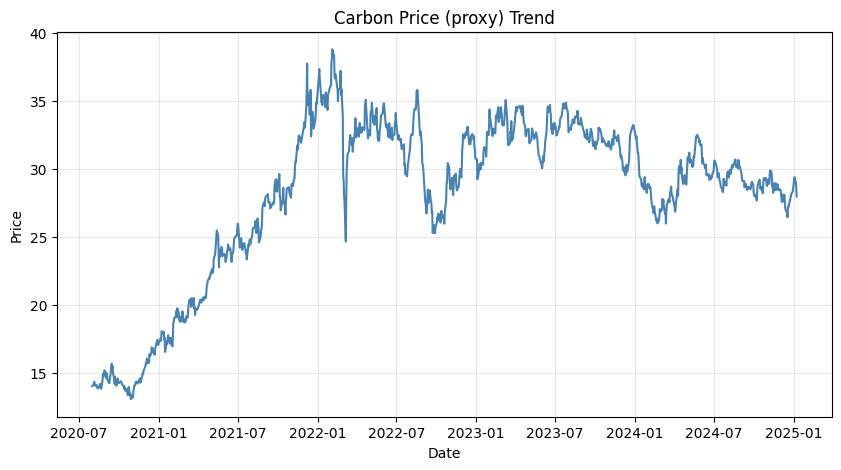

In [4]:
plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["CARBON_PRICE"], color="steelblue")
plt.title("Carbon Price (proxy) Trend")
plt.xlabel("Date"); plt.ylabel("Price")
plt.grid(alpha=0.3)
plt.show()

In [5]:
desc = df[["CARBON_PRICE", "FINANCIAL_INDEX", "OIL_PRICE", "GAS_PRICE"]].describe().T
desc = desc[["max", "min", "mean", "std"]]
desc.columns = ["Max", "Min", "Mean", "Std_dev"]
print(desc)

                         Max          Min         Mean     Std_dev
CARBON_PRICE       38.833652    13.084694    28.137515    6.011157
FINANCIAL_INDEX  5100.899902  2958.209961  4143.310484  511.200398
OIL_PRICE         123.699997    35.790001    75.330797   16.278599
GAS_PRICE           9.680000     1.575000     3.714176    1.849867


In [6]:
def adf_report(series, name):
    result = adfuller(series.dropna())
    print(f"{name}: ADF stat = {result[0]:.4f}, p-value = {result[1]:.4f}")
    return result[1]

adf_report(df["CARBON_PRICE"], "CARBON_PRICE (level)")
adf_report(df["CARBON_PRICE"].diff(), "CARBON_PRICE (1st diff)")

CARBON_PRICE (level): ADF stat = -2.4718, p-value = 0.1225
CARBON_PRICE (1st diff): ADF stat = -14.6744, p-value = 0.0000


np.float64(3.2292034990073364e-27)

In [7]:
n = len(df)
train_size = int(n * 0.6)   # paper dùng ~60% train / 40% test

train_df = df.iloc[:train_size].reset_index(drop=True)
test_df  = df.iloc[train_size:].reset_index(drop=True)

print("Train size:", len(train_df), "| Test size:", len(test_df))

Train size: 655 | Test size: 437


In [8]:
from tensorflow.keras.layers import RepeatVector, Flatten
from tensorflow.keras.optimizers import Adam

In [9]:
feature_cols = ["CARBON_PRICE", "FINANCIAL_INDEX", "OIL_PRICE", "GAS_PRICE"]
lookback = 10   # số ngày quá khứ dùng làm input

def create_windows(data, feature_cols, target_col, lookback):
    X, y, dates = [], [], []
    values = data[feature_cols].values
    target = data[target_col].values
    date_arr = data["Date"].values
    for i in range(lookback, len(data)):
        X.append(values[i-lookback:i, :])
        y.append(target[i])
        dates.append(date_arr[i])
    return np.array(X), np.array(y), np.array(dates)

X_all, y_all, dates_all = create_windows(df, feature_cols, "CARBON_PRICE", lookback)
print("X_all shape:", X_all.shape, "| y_all shape:", y_all.shape)

# Chia lại theo đúng tỉ lệ train/test đã xác định ở Bước 7
split_idx = train_size - lookback   # điều chỉnh vì windows bị lệch do lookback

X_train, X_test = X_all[:split_idx], X_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]
dates_test = dates_all[split_idx:]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_all shape: (1082, 10, 4) | y_all shape: (1082,)
X_train: (645, 10, 4) | X_test: (437, 10, 4)


In [10]:
n_features = X_train.shape[2]

scaler_X = MinMaxScaler()
X_train_flat = X_train.reshape(-1, n_features)
scaler_X.fit(X_train_flat)

def scale_X(X):
    shape = X.shape
    X_flat = X.reshape(-1, n_features)
    X_scaled = scaler_X.transform(X_flat)
    return X_scaled.reshape(shape)

X_train_s = scale_X(X_train)
X_test_s  = scale_X(X_test)

scaler_y = MinMaxScaler()
y_train_s = scaler_y.fit_transform(y_train.reshape(-1,1))
y_test_s  = scaler_y.transform(y_test.reshape(-1,1))

# Dạng flatten dùng cho RF / XGBoost / SVR
X_train_flat2d = X_train_s.reshape(X_train_s.shape[0], -1)
X_test_flat2d  = X_test_s.reshape(X_test_s.shape[0], -1)

print("Flattened train shape:", X_train_flat2d.shape)

Flattened train shape: (645, 40)


In [11]:
history = list(train_df["CARBON_PRICE"])
arima_preds = []

for t in range(len(test_df)):
    model = ARIMA(history, order=(1,1,1))
    fitted = model.fit()
    yhat = fitted.forecast(steps=1)[0]
    arima_preds.append(yhat)
    history.append(test_df["CARBON_PRICE"].iloc[t])

arima_preds = np.array(arima_preds)
actual_arima = test_df["CARBON_PRICE"].values

print("ARIMA done. Test length:", len(arima_preds))

ARIMA done. Test length: 437


In [12]:
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=80,
    random_state=42
)
rf_model.fit(X_train_flat2d, y_train)
rf_preds = rf_model.predict(X_test_flat2d)

print("RF done.")

RF done.


In [13]:
xgb_model = xgb.XGBRegressor(
    n_estimators=120,
    max_depth=40,
    learning_rate=0.05,
    reg_alpha=0.02,
    random_state=42
)
xgb_model.fit(X_train_flat2d, y_train)
xgb_preds = xgb_model.predict(X_test_flat2d)

print("XGBoost done.")

XGBoost done.


In [14]:
svr_model = SVR(kernel="rbf", C=1.2, tol=0.0001)
svr_model.fit(X_train_flat2d, y_train_s.ravel())
svr_preds_s = svr_model.predict(X_test_flat2d)
svr_preds = scaler_y.inverse_transform(svr_preds_s.reshape(-1,1)).flatten()

print("SVR done.")

SVR done.


In [15]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

# Set random seed đúng như bài báo
SEED = 20210611
np.random.seed(SEED)
tf.random.set_seed(SEED)

def build_lstm_5layers(input_shape, hidden_size=100, activation="relu"):
    model = Sequential()
    # Layer 1
    model.add(LSTM(hidden_size, activation=activation,
                    return_sequences=True, input_shape=input_shape,
                    name="lstm_layer1"))
    model.add(Dropout(0.2, name="dropout1"))
    # Layer 2
    model.add(LSTM(hidden_size, activation=activation,
                    return_sequences=True, name="lstm_layer2"))
    model.add(Dropout(0.2, name="dropout2"))
    # Layer 3
    model.add(LSTM(hidden_size, activation=activation,
                    return_sequences=True, name="lstm_layer3"))
    model.add(Dropout(0.2, name="dropout3"))
    # Layer 4
    model.add(LSTM(hidden_size, activation=activation,
                    return_sequences=True, name="lstm_layer4"))
    model.add(Dropout(0.2, name="dropout4"))
    # Layer 5 (lớp cuối, return_sequences=False để ra vector duy nhất)
    model.add(LSTM(hidden_size, activation=activation,
                    return_sequences=False, name="lstm_layer5"))
    model.add(Dropout(0.2, name="dropout5"))
    # Output layer
    model.add(Dense(1, name="output_layer"))
    return model


lstm_model = build_lstm_5layers(input_shape=(lookback, n_features),
                                 hidden_size=100, activation="relu")

lstm_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="mse"
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer1 (LSTM)              │ (None, 10, 100)        │        42,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 10, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer2 (LSTM)              │ (None, 10, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 10, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer3 (LSTM)              │ (None, 10, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3 (Dropout)              │ (None, 10, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer4 (LSTM)              │ (None, 10, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout4 (Dropout)              │ (None, 10, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer5 (LSTM)              │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout5 (Dropout)              │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 363,701 (1.39 MB)

 Trainable params: 363,701 (1.39 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=50,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_s, y_train_s,
    validation_split=0.1,
    epochs=2000,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 343ms/step - loss: 0.3271 - val_loss: 0.5595
Epoch 2/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - loss: 0.3215 - val_loss: 0.5505
Epoch 3/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - loss: 0.3153 - val_loss: 0.5406
Epoch 4/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - loss: 0.3084 - val_loss: 0.5292
Epoch 5/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - loss: 0.3005 - val_loss: 0.5158
Epoch 6/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - loss: 0.2909 - val_loss: 0.4997
Epoch 7/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - loss: 0.2796 - val_loss: 0.4802
Epoch 8/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - loss: 0.2659 - val_loss: 0.4563
Epoch 9/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - loss: 0.2491 - val_loss: 0.4267
Epoch 10/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - loss: 0.2290 - val_loss: 0.3894
Epoch 11/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - loss: 0.2018 - val_loss: 0.3413
Epoch 12/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/ste

In [18]:
lstm_preds_s = lstm_model.predict(X_test_s)
lstm_preds = scaler_y.inverse_transform(lstm_preds_s).flatten()

print("LSTM (5-layer, full paper config) done. Length:", len(lstm_preds))

14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step
LSTM (5-layer, full paper config) done. Length: 437


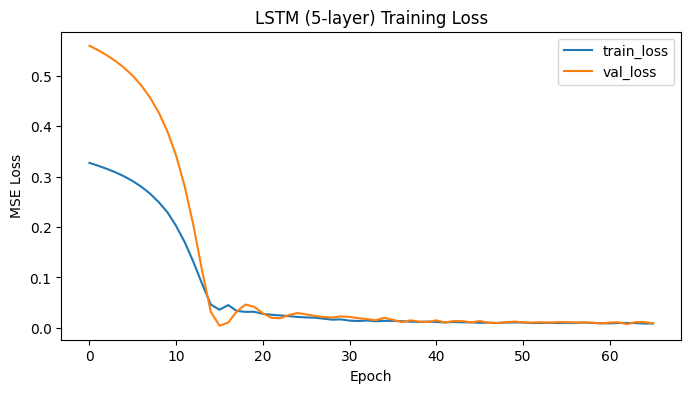

In [19]:
plt.figure(figsize=(8,4))
plt.plot(history_lstm.history["loss"], label="train_loss")
plt.plot(history_lstm.history["val_loss"], label="val_loss")
plt.title("LSTM (5-layer) Training Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [21]:
from tensorflow.keras.layers import RepeatVector, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [22]:
def tcn_block(x, filters, kernel_size, dilation_rate, name_prefix):
    conv = Conv1D(filters=filters, kernel_size=kernel_size,
                   dilation_rate=dilation_rate, padding="causal",
                   name=f"{name_prefix}_dilated_conv")(x)
    conv = BatchNormalization(name=f"{name_prefix}_bn")(conv)
    conv = Activation("relu", name=f"{name_prefix}_relu")(conv)
    conv = Dropout(0.2, name=f"{name_prefix}_dropout")(conv)

    if x.shape[-1] != filters:
        x = Conv1D(filters=filters, kernel_size=1, padding="same",
                    name=f"{name_prefix}_residual_proj")(x)

    out = Add(name=f"{name_prefix}_residual_add")([x, conv])
    return out


def build_tcn_seq2seq(input_shape,
                       encoder_channels=120, encoder_kernel=5,
                       decoder_channels=150, decoder_kernel=2,
                       dilations=[1, 2, 4, 8]):

    # ---------- ENCODER ----------
    encoder_input = Input(shape=input_shape, name="encoder_input")
    x = encoder_input
    for i, d in enumerate(dilations):
        x = tcn_block(x, filters=encoder_channels, kernel_size=encoder_kernel,
                       dilation_rate=d, name_prefix=f"encoder_block{i+1}")

    # Intermediate Vector (giống 'z' trong Fig. 2/4 của bài báo)
    intermediate_vector = x[:, -1, :]

    # ---------- DECODER ----------
    output_length = 1
    decoder_input = RepeatVector(output_length, name="repeat_intermediate")(intermediate_vector)

    y = decoder_input
    for i, d in enumerate([1, 2]):
        y = tcn_block(y, filters=decoder_channels, kernel_size=decoder_kernel,
                       dilation_rate=d, name_prefix=f"decoder_block{i+1}")

    y = Flatten(name="decoder_flatten")(y)
    output = Dense(1, name="final_output")(y)

    model = Model(inputs=encoder_input, outputs=output, name="TCN_Seq2Seq")
    return model


tcn_seq2seq_model = build_tcn_seq2seq(
    input_shape=(lookback, n_features),
    encoder_channels=120, encoder_kernel=5,
    decoder_channels=150, decoder_kernel=2,
    dilations=[1, 2, 4, 8]
)

tcn_seq2seq_model.compile(
    optimizer=Adam(learning_rate=0.005),
    loss="mse"
)

tcn_seq2seq_model.summary()

Model: "TCN_Seq2Seq"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 10, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_dil… │ (None, 10, 120)   │      2,520 │ encoder_input[0]… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_bn   │ (None, 10, 120)   │        480 │ encoder_block1_d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_relu │ (None, 10, 120)   │          0 │ encoder_block1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_res… │ (None, 10, 120)   │        600 │ encoder_input[0]… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_dro… │ (None, 10, 120)   │          0 │ encoder_block1_r… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block1_res… │ (None, 10, 120)   │          0 │ encoder_block1_r… │
│ (Add)               │                   │            │ encoder_block1_d… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_dil… │ (None, 10, 120)   │     72,120 │ encoder_block1_r… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_bn   │ (None, 10, 120)   │        480 │ encoder_block2_d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_relu │ (None, 10, 120)   │          0 │ encoder_block2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_dro… │ (None, 10, 120)   │          0 │ encoder_block2_r… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block2_res… │ (None, 10, 120)   │          0 │ encoder_block1_r… │
│ (Add)               │                   │            │ encoder_block2_d… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block3_dil… │ (None, 10, 120)   │     72,120 │ encoder_block2_r… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block3_bn   │ (None, 10, 120)   │        480 │ encoder_block3_d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block3_relu │ (None, 10, 120)   │          0 │ encoder_block3_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block3_dro… │ (None, 10, 120)   │          0 │ encoder_block3_r… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block3_res… │ (None, 10, 120)   │          0 │ encoder_block2_r

 Total params: 322,201 (1.23 MB)

 Trainable params: 320,641 (1.22 MB)

 Non-trainable params: 1,560 (6.09 KB)

In [23]:
early_stop_tcn = EarlyStopping(
    monitor="val_loss",
    patience=50,
    restore_best_weights=True
)

history_tcn = tcn_seq2seq_model.fit(
    X_train_s, y_train_s,
    validation_split=0.1,
    epochs=2000,
    batch_size=128,
    callbacks=[early_stop_tcn],
    verbose=1
)

Epoch 1/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 261ms/step - loss: 369.6377 - val_loss: 0.4905
Epoch 2/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - loss: 39.4811 - val_loss: 0.0749
Epoch 3/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - loss: 5.0600 - val_loss: 0.5144
Epoch 4/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - loss: 1.4785 - val_loss: 0.7782
Epoch 5/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - loss: 1.7482 - val_loss: 0.5287
Epoch 6/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - loss: 0.5317 - val_loss: 0.3041
Epoch 7/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - loss: 0.4936 - val_loss: 0.3444
Epoch 8/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - loss: 0.6026 - val_loss: 0.4094
Epoch 9/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step - loss: 0.3819 - val_loss: 0.4318
Epoch 10/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step - loss: 0.3641 - val_loss: 0.4140
Epoch 11/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - loss: 0.3464 - val_loss: 0.3629
Epoch 12/2000
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/

In [24]:
tcn_preds_s = tcn_seq2seq_model.predict(X_test_s)
tcn_preds = scaler_y.inverse_transform(tcn_preds_s).flatten()

print("TCN-Seq2Seq prediction done. Length:", len(tcn_preds))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
TCN-Seq2Seq prediction done. Length: 437


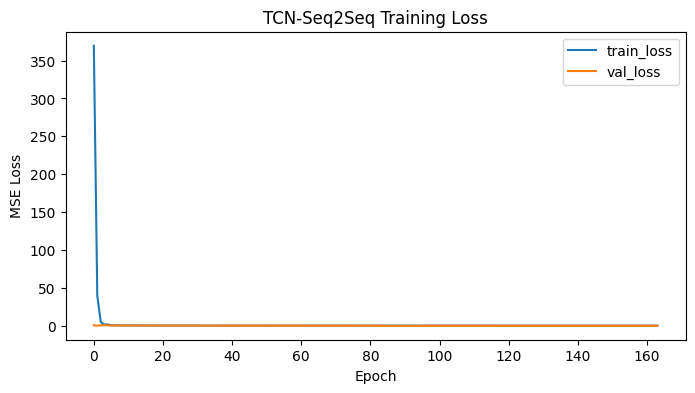

In [25]:
plt.figure(figsize=(8,4))
plt.plot(history_tcn.history["loss"], label="train_loss")
plt.plot(history_tcn.history["val_loss"], label="val_loss")
plt.title("TCN-Seq2Seq Training Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [26]:
def compute_DA(actual, pred):
    correct = 0
    for t in range(len(actual)-1):
        real_dir = (actual[t+1] - actual[t])
        pred_dir = (pred[t+1] - actual[t])
        if real_dir * pred_dir >= 0:
            correct += 1
    return correct / (len(actual)-1) * 100

def compute_MAPE(actual, pred):
    return np.mean(np.abs((actual - pred) / actual))

def compute_RMSE(actual, pred):
    return np.sqrt(mean_squared_error(actual, pred))

results = {}
model_preds = {
    "ARIMA": arima_preds,
    "RF": rf_preds,
    "XGBoost": xgb_preds,
    "SVR": svr_preds,
    "LSTM": lstm_preds,
    "TCN-Seq2Seq": tcn_preds,
}

for name, preds in model_preds.items():
    actual = actual_arima if name == "ARIMA" else y_test
    da = compute_DA(actual, preds)
    mape = compute_MAPE(actual, preds)
    rmse = compute_RMSE(actual, preds)
    results[name] = {"DA (%)": da, "MAPE": mape, "RMSE": rmse}

results_table = pd.DataFrame(results).T
print(results_table)

                DA (%)      MAPE      RMSE
ARIMA        45.871560  0.010937  0.425747
RF           48.623853  0.013860  0.537901
XGBoost      53.899083  0.016712  0.636065
SVR          51.146789  0.029422  1.179232
LSTM         46.559633  0.104737  3.641774
TCN-Seq2Seq  45.412844  0.044300  1.687950


In [27]:
from tensorflow.keras.regularizers import l2

def tcn_block_v2(x, filters, kernel_size, dilation_rate, name_prefix, l2_reg=1e-4):
    conv = Conv1D(filters=filters, kernel_size=kernel_size,
                   dilation_rate=dilation_rate, padding="causal",
                   kernel_regularizer=l2(l2_reg),
                   name=f"{name_prefix}_dilated_conv")(x)
    conv = BatchNormalization(name=f"{name_prefix}_bn")(conv)
    conv = Activation("relu", name=f"{name_prefix}_relu")(conv)
    conv = Dropout(0.3, name=f"{name_prefix}_dropout")(conv)   # tăng nhẹ dropout 0.2->0.3

    if x.shape[-1] != filters:
        x = Conv1D(filters=filters, kernel_size=1, padding="same",
                    kernel_regularizer=l2(l2_reg),
                    name=f"{name_prefix}_residual_proj")(x)

    out = Add(name=f"{name_prefix}_residual_add")([x, conv])
    return out


def build_tcn_seq2seq_v2(input_shape,
                          encoder_channels=32, encoder_kernel=3,
                          decoder_channels=32, decoder_kernel=2,
                          dilations=[1, 2, 4], l2_reg=1e-4):

    # ---------- ENCODER ----------
    encoder_input = Input(shape=input_shape, name="encoder_input_v2")
    x = encoder_input
    for i, d in enumerate(dilations):
        x = tcn_block_v2(x, filters=encoder_channels, kernel_size=encoder_kernel,
                          dilation_rate=d, name_prefix=f"enc2_block{i+1}", l2_reg=l2_reg)

    intermediate_vector = x[:, -1, :]

    # ---------- DECODER ----------
    output_length = 1
    decoder_input = RepeatVector(output_length, name="repeat_intermediate_v2")(intermediate_vector)

    y = decoder_input
    for i, d in enumerate([1, 2]):
        y = tcn_block_v2(y, filters=decoder_channels, kernel_size=decoder_kernel,
                          dilation_rate=d, name_prefix=f"dec2_block{i+1}", l2_reg=l2_reg)

    y = Flatten(name="decoder_flatten_v2")(y)
    output = Dense(1, name="final_output_v2")(y)

    model = Model(inputs=encoder_input, outputs=output, name="TCN_Seq2Seq_v2")
    return model


tcn_seq2seq_model_v2 = build_tcn_seq2seq_v2(
    input_shape=(lookback, n_features),
    encoder_channels=32, encoder_kernel=3,
    decoder_channels=32, decoder_kernel=2,
    dilations=[1, 2, 4],
    l2_reg=1e-4
)

tcn_seq2seq_model_v2.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="mse"
)

tcn_seq2seq_model_v2.summary()

Model: "TCN_Seq2Seq_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input_v2    │ (None, 10, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_block1_dilate… │ (None, 10, 32)    │        416 │ encoder_input_v2… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_block1_bn      │ (None, 10, 32)    │        128 │ enc2_block1_dila… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_block1_relu    │ (None, 10, 32)    │          0 │ enc2_block1_bn[0… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_block1_residu… │ (None, 10, 32)    │        160 │ encoder_input_v2… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_block1_dropout │ (None, 10, 32)    │          0 │ enc2_block1_relu… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_block1_residu… │ (None, 10, 32)    │          0 │ enc2_block1_resi… │
│ (Add)               │                   │            │ enc2_block1_drop… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_block2_dilate… │ (None, 10, 32)    │      3,104 │ enc2_block1_resi… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_block2_bn      │ (None, 10, 32)    │        128 │ enc2_block2_dila… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_block2_relu    │ (None, 10, 32)    │          0 │ enc2_block2_bn[0… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_block2_dropout │ (None, 10, 32)    │          0 │ enc2_block2_relu… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_block2_residu… │ (None, 10, 32)    │          0 │ enc2_block1_resi… │
│ (Add)               │                   │            │ enc2_block2_drop… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_block3_dilate… │ (None, 10, 32)    │      3,104 │ enc2_block2_resi… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_block3_bn      │ (None, 10, 32)    │        128 │ enc2_block3_dila… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_block3_relu    │ (None, 10, 32)    │          0 │ enc2_block3_bn[0… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_block3_dropout │ (None, 10, 32)    │          0 │ enc2_block3_relu… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_block3_residu… │ (None, 10, 32)    │          0 │ enc2_block2_resi

 Total params: 11,617 (45.38 KB)

 Trainable params: 11,297 (44.13 KB)

 Non-trainable params: 320 (1.25 KB)

In [28]:
early_stop_tcn_v2 = EarlyStopping(
    monitor="val_loss",
    patience=50,
    restore_best_weights=True
)

history_tcn_v2 = tcn_seq2seq_model_v2.fit(
    X_train_s, y_train_s,
    validation_split=0.1,
    epochs=2000,
    batch_size=32,        # giảm từ 128 -> 32
    callbacks=[early_stop_tcn_v2],
    verbose=1
)

Epoch 1/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - loss: 4.2941 - val_loss: 1.0554
Epoch 2/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.5335 - val_loss: 0.5287
Epoch 3/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8450 - val_loss: 0.3061
Epoch 4/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.6404 - val_loss: 0.1823
Epoch 5/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.5299 - val_loss: 0.0986
Epoch 6/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1094 - val_loss: 0.0559
Epoch 7/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.1144 - val_loss: 0.0296
Epoch 8/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9134 - val_loss: 0.0273
Epoch 9/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9160 - val_loss: 0.0295
Epoch 10/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.7694 - val_loss: 0.0294
Epoch 11/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7472 - val_loss: 0.0377
Epoch 12/2000
19/19 ━━━━━━━━━━━━━━━━━━━━ 

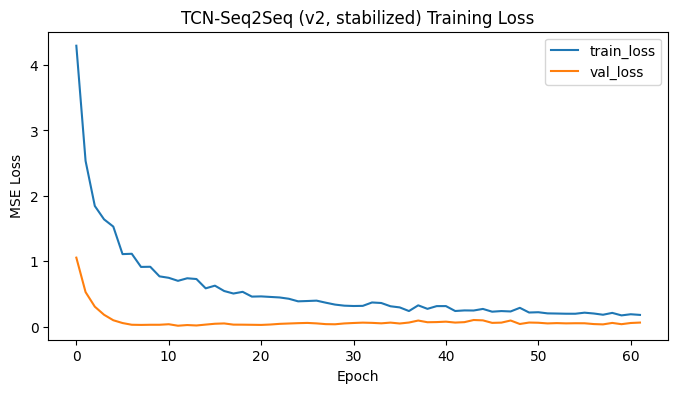

In [29]:
plt.figure(figsize=(8,4))
plt.plot(history_tcn_v2.history["loss"], label="train_loss")
plt.plot(history_tcn_v2.history["val_loss"], label="val_loss")
plt.title("TCN-Seq2Seq (v2, stabilized) Training Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [31]:
tcn_preds_s_v2 = tcn_seq2seq_model_v2.predict(X_test_s)
tcn_preds_v2 = scaler_y.inverse_transform(tcn_preds_s_v2).flatten()

print("TCN-Seq2Seq (v2, stabilized) done. Length:", len(tcn_preds_v2))

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step
TCN-Seq2Seq (v2, stabilized) done. Length: 437


In [32]:
def compute_DA(actual, pred):
    correct = 0
    for t in range(len(actual)-1):
        real_dir = (actual[t+1] - actual[t])
        pred_dir = (pred[t+1] - actual[t])
        if real_dir * pred_dir >= 0:
            correct += 1
    return correct / (len(actual)-1) * 100

def compute_MAPE(actual, pred):
    return np.mean(np.abs((actual - pred) / actual))

def compute_RMSE(actual, pred):
    return np.sqrt(mean_squared_error(actual, pred))

results = {}
model_preds = {
    "ARIMA": arima_preds,
    "RF": rf_preds,
    "XGBoost": xgb_preds,
    "SVR": svr_preds,
    "LSTM": lstm_preds,
    "TCN-Seq2Seq": tcn_preds_v2,   # <-- dùng bản v2 đã ổn định
}

for name, preds in model_preds.items():
    actual = actual_arima if name == "ARIMA" else y_test
    da = compute_DA(actual, preds)
    mape = compute_MAPE(actual, preds)
    rmse = compute_RMSE(actual, preds)
    results[name] = {"DA (%)": da, "MAPE": mape, "RMSE": rmse}

results_table = pd.DataFrame(results).T
print(results_table)

                DA (%)      MAPE      RMSE
ARIMA        45.871560  0.010937  0.425747
RF           48.623853  0.013860  0.537901
XGBoost      53.899083  0.016712  0.636065
SVR          51.146789  0.029422  1.179232
LSTM         46.559633  0.104737  3.641774
TCN-Seq2Seq  54.128440  0.098186  3.800366


In [33]:
print("Train CARBON_PRICE range:", y_train.min(), "-", y_train.max())
print("Test CARBON_PRICE range:", y_test.min(), "-", y_test.max())

Train CARBON_PRICE range: 13.084693908691406 - 38.83365249633789
Test CARBON_PRICE range: 26.00994873046875 - 34.905052185058594


In [34]:
print("=== LSTM predictions ===")
print("Mean predicted:", lstm_preds.mean(), "| Std predicted:", lstm_preds.std())
print("Mean actual (y_test):", y_test.mean(), "| Std actual:", y_test.std())

print("\n=== TCN-Seq2Seq (v2) predictions ===")
print("Mean predicted:", tcn_preds_v2.mean(), "| Std predicted:", tcn_preds_v2.std())
print("Mean actual (y_test):", y_test.mean(), "| Std actual:", y_test.std())

=== LSTM predictions ===
Mean predicted: 32.670334 | Std predicted: 1.2149936
Mean actual (y_test): 30.58849947949023 | Std actual: 2.194004679932926

=== TCN-Seq2Seq (v2) predictions ===
Mean predicted: 27.871702 | Std predicted: 4.0091867
Mean actual (y_test): 30.58849947949023 | Std actual: 2.194004679932926


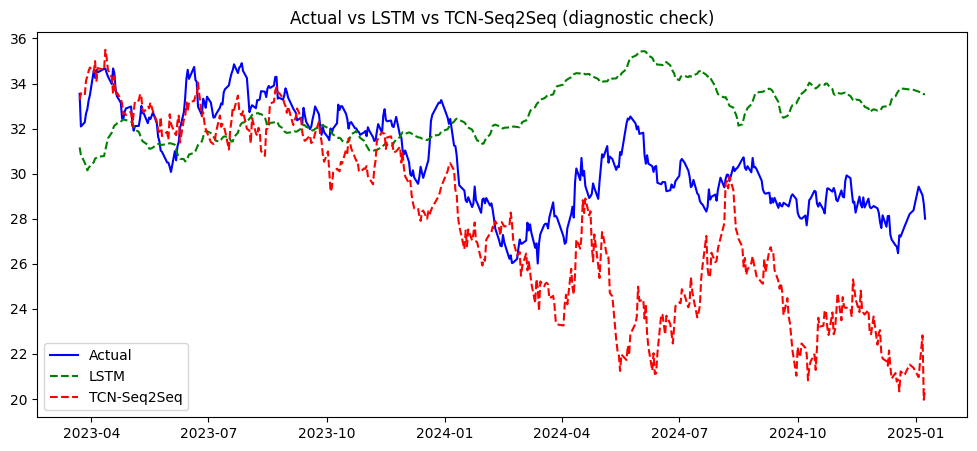

In [35]:
plt.figure(figsize=(12,5))
plt.plot(dates_test, y_test, label="Actual", color="blue")
plt.plot(dates_test, lstm_preds, label="LSTM", linestyle="--", color="green")
plt.plot(dates_test, tcn_preds_v2, label="TCN-Seq2Seq", linestyle="--", color="red")
plt.title("Actual vs LSTM vs TCN-Seq2Seq (diagnostic check)")
plt.legend()
plt.show()

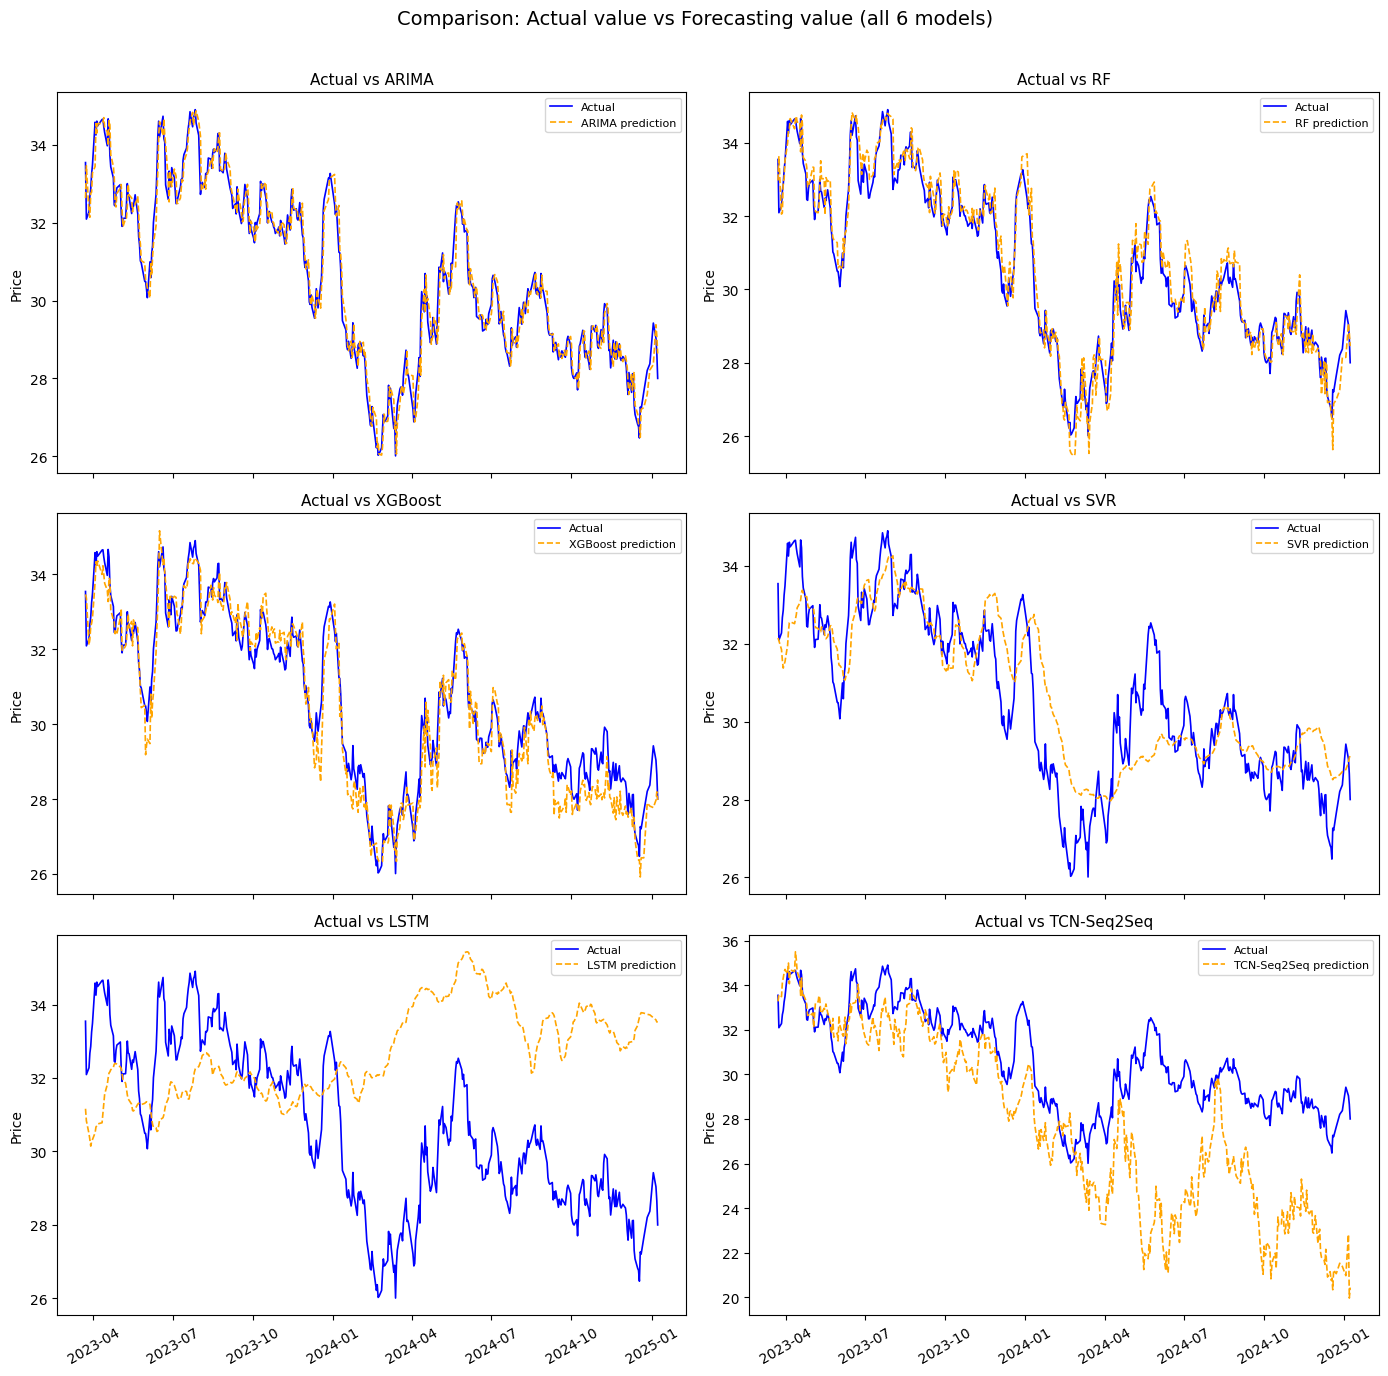

In [36]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14), sharex=True)

model_list = ["ARIMA", "RF", "XGBoost", "SVR", "LSTM", "TCN-Seq2Seq"]
model_preds_final = {
    "ARIMA": arima_preds,
    "RF": rf_preds,
    "XGBoost": xgb_preds,
    "SVR": svr_preds,
    "LSTM": lstm_preds,
    "TCN-Seq2Seq": tcn_preds_v2,
}

for ax, name in zip(axes.flatten(), model_list):
    preds = model_preds_final[name]
    if name == "ARIMA":
        actual = actual_arima
        d = test_df["Date"].values
    else:
        actual = y_test
        d = dates_test
    ax.plot(d, actual, label="Actual", color="blue", linewidth=1.2)
    ax.plot(d, preds, label=f"{name} prediction", color="orange",
             linewidth=1.2, linestyle="--")
    ax.set_title(f"Actual vs {name}", fontsize=11)
    ax.set_ylabel("Price")
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle("Comparison: Actual value vs Forecasting value (all 6 models)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [37]:
results_table_display = results_table.copy()
results_table_display["DA (%)"] = results_table_display["DA (%)"].round(2)
results_table_display["MAPE"] = results_table_display["MAPE"].round(4)
results_table_display["RMSE"] = results_table_display["RMSE"].round(4)

print("="*50)
print("BẢNG KẾT QUẢ SO SÁNH CÁC MÔ HÌNH (Table 4 tái hiện)")
print("="*50)
print(results_table_display.to_string())
print("="*50)

# Xác định mô hình tốt nhất theo từng tiêu chí
best_da = results_table_display["DA (%)"].idxmax()
best_mape = results_table_display["MAPE"].idxmin()
best_rmse = results_table_display["RMSE"].idxmin()

print(f"\nMô hình có DA cao nhất: {best_da} ({results_table_display.loc[best_da, 'DA (%)']}%)")
print(f"Mô hình có MAPE thấp nhất: {best_mape} ({results_table_display.loc[best_mape, 'MAPE']})")
print(f"Mô hình có RMSE thấp nhất: {best_rmse} ({results_table_display.loc[best_rmse, 'RMSE']})")

BẢNG KẾT QUẢ SO SÁNH CÁC MÔ HÌNH (Table 4 tái hiện)
             DA (%)    MAPE    RMSE
ARIMA         45.87  0.0109  0.4257
RF            48.62  0.0139  0.5379
XGBoost       53.90  0.0167  0.6361
SVR           51.15  0.0294  1.1792
LSTM          46.56  0.1047  3.6418
TCN-Seq2Seq   54.13  0.0982  3.8004

Mô hình có DA cao nhất: TCN-Seq2Seq (54.13%)
Mô hình có MAPE thấp nhất: ARIMA (0.0109)
Mô hình có RMSE thấp nhất: ARIMA (0.4257)


In [38]:
results_table_display.to_csv("model_comparison_results.csv")
print("Đã lưu file: model_comparison_results.csv")

from google.colab import files
files.download("model_comparison_results.csv")

Đã lưu file: model_comparison_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>